# EffortScope

## 1. Project Overview

Bu notebook, musteri destek ticket verilerini analiz ederek efor modelleme, kaynak analizi, musteri segmentasyonu ve tahminleme calismalari uretmek icin hazirlanmistir.

Calisma yaklasimi:
- Kaggle dataset'i kod ile otomatik indirilir.
- CSV dosyasi klasor icinde otomatik bulunur.
- Kolon isimleri farkli olsa bile benzer kolonlar eslestirilmeye calisilir.
- Gercek efor alani bulunmadigi icin sentetik ama gercekci bir efor modeli olusturulur.
- EDA, NLP, Pareto, kumeleme ve regresyon modelleme birlikte uygulanir.


## 2. How to Use

Bu notebook'u calistirmak icin hucreleri yukaridan asagiya sirayla calistirmaniz yeterlidir.

Notlar:
- Dataset manuel yuklenmez.
- KaggleHub ile otomatik indirme yapilir.
- Kolon isimleri beklenenden farkliysa fallback mekanizmalari devreye girer.
- Aciklamalar Turkce, kod bloklari English hazirlanmistir.


In [1]:
%pip install -q kagglehub wordcloud seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


## 3. Data Loading

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import Markdown, display
except Exception:
    def Markdown(text):
        return text

    def display(*args, **kwargs):
        return None

from wordcloud import WordCloud
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


def find_best_csv(root_path: str | Path) -> Path:
    root = Path(root_path)
    csv_files = sorted(root.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found under: {root}")

    def sort_key(file_path: Path):
        try:
            size = file_path.stat().st_size
        except OSError:
            size = 0
        return (-size, len(file_path.parts), file_path.name.lower())

    return sorted(csv_files, key=sort_key)[0]


dataset_path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")
csv_path = find_best_csv(dataset_path)
df = pd.read_csv(csv_path)

print(f"Dataset folder: {dataset_path}")
print(f"Selected CSV: {csv_path.name}")
print(f"Shape: {df.shape}")
display(df.head())


C:\Users\Kadir\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset folder: C:\Users\Kadir\.cache\kagglehub\datasets\tobiasbueck\multilingual-customer-support-tickets\versions\14
Selected CSV: aa_dataset-tickets-multi-lang-5-2-50-version.csv
Shape: (28587, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


## 4. Column Mapping Guide

Bu bolumde dataset kolonlari otomatik olarak yorumlanir. Amac, farkli isimlendirmelere ragmen benzer anlam tasiyan kolonlari tespit etmektir.

Ornek eslestirme mantigi:
- `description` benzeri kolonlar: `description`, `ticket_description`, `body`, `message`, `text`
- `priority` benzeri kolonlar: `priority`, `severity`, `urgency`, `importance`
- `customer` benzeri kolonlar: `customer`, `account`, `client`, `organization`

Eger dogrudan uygun kolon bulunamazsa notebook fallback mekanizmasi kullanir ve akisi durdurmaz.


In [3]:
def normalize_name(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())


def find_column(columns, keywords, preferred_dtypes=None):
    normalized = {col: normalize_name(col) for col in columns}
    scored = []

    for col, norm in normalized.items():
        score = 0
        for keyword in keywords:
            k = normalize_name(keyword)
            if norm == k:
                score += 100
            elif k in norm:
                score += 20
        if score > 0:
            scored.append((score, col))

    if scored:
        scored.sort(reverse=True)
        return scored[0][1]

    if preferred_dtypes:
        dtype_candidates = [
            col for col in columns
            if any(dtype in str(df[col].dtype).lower() for dtype in preferred_dtypes)
        ]
        if dtype_candidates:
            return dtype_candidates[0]
    return None


column_map = {
    "description": find_column(
        df.columns,
        ["description", "ticket_description", "body", "message", "text", "issue", "problem"],
        preferred_dtypes=["object", "string"]
    ),
    "priority": find_column(
        df.columns,
        ["priority", "severity", "urgency", "importance", "impact"],
        preferred_dtypes=["object", "string"]
    ),
    "language": find_column(
        df.columns,
        ["language", "lang", "locale"],
        preferred_dtypes=["object", "string"]
    ),
    "product": find_column(
        df.columns,
        ["product", "service", "category", "topic", "issue_type"],
        preferred_dtypes=["object", "string"]
    ),
    "date": find_column(
        df.columns,
        ["created_at", "created", "date", "timestamp", "opened_at"]
    )
}

text_fallback = df.select_dtypes(include=["object", "string"]).fillna("").astype(str)
if column_map["description"] is None:
    if text_fallback.shape[1] > 0:
        df["fallback_description"] = text_fallback.apply(
            lambda row: " ".join([x for x in row if x.strip()]), axis=1
        )
    else:
        df["fallback_description"] = "support ticket"
    column_map["description"] = "fallback_description"

if column_map["priority"] is None:
    df["fallback_priority"] = pd.Series(
        rng.choice(["low", "medium", "high", "critical"], size=len(df), p=[0.30, 0.40, 0.22, 0.08])
    )
    column_map["priority"] = "fallback_priority"

mapping_df = pd.DataFrame({
    "logical_field": list(column_map.keys()),
    "mapped_column": list(column_map.values())
})

display(mapping_df)


,logical_field,mapped_column
0,description,body
1,priority,priority
2,language,language
3,product,NaN
4,date,NaN


## 5. Data Cleaning

In [4]:
df = df.copy()
df.columns = [str(col).strip() for col in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

description_col = column_map["description"]
priority_col = column_map["priority"]
language_col = column_map["language"]
product_col = column_map["product"]
date_col = column_map["date"]

df[description_col] = df[description_col].fillna("support ticket").astype(str).str.strip()
df.loc[df[description_col].eq(""), description_col] = "support ticket"
df[priority_col] = df[priority_col].fillna("medium").astype(str).str.strip().str.lower()

priority_normalization = {
    "low": "low",
    "medium": "medium",
    "med": "medium",
    "normal": "medium",
    "high": "high",
    "urgent": "high",
    "critical": "critical",
    "sev1": "critical",
    "sev2": "high",
    "sev3": "medium",
    "sev4": "low"
}

df[priority_col] = df[priority_col].map(lambda x: priority_normalization.get(x, x))
valid_priorities = {"low", "medium", "high", "critical"}
df.loc[~df[priority_col].isin(valid_priorities), priority_col] = "medium"

if language_col is not None:
    df[language_col] = df[language_col].fillna("unknown").astype(str).str.strip()

if product_col is not None:
    df[product_col] = df[product_col].fillna("unknown").astype(str).str.strip()

if date_col is not None:
    parsed_dates = pd.to_datetime(df[date_col], errors="coerce")
    if parsed_dates.notna().sum() > 0:
        df["created_at_clean"] = parsed_dates
    else:
        date_col = None

print(f"Rows after cleaning: {len(df):,}")
display(df.head())


Rows after cleaning: 28,587


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


## 6. Missing Values

,column,missing_count,missing_ratio
0,tag_8,28022,0.980236
1,tag_7,26547,0.928639
2,tag_6,22713,0.794522
3,tag_5,14042,0.491202
4,subject,3838,0.134257
5,tag_4,3058,0.106972
6,tag_3,136,0.004757
7,tag_2,13,0.000455
8,answer,7,0.000245
9,language,0,0.000000


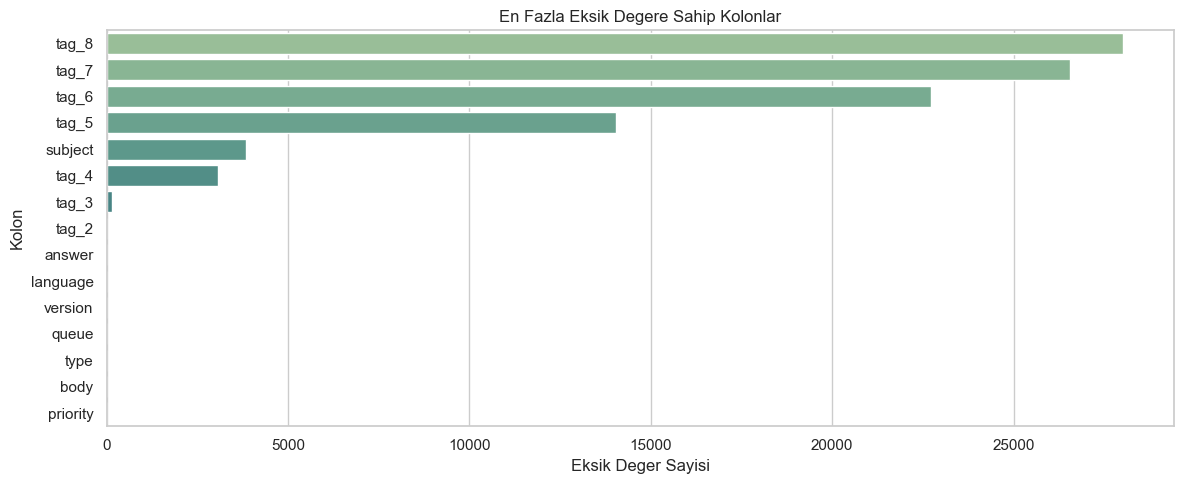

In [5]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df)

display(missing_summary.head(15))

plt.figure(figsize=(12, 5))
sns.barplot(data=missing_summary.head(15), x="missing_count", y="column", palette="crest")
plt.title("En Fazla Eksik Degere Sahip Kolonlar")
plt.xlabel("Eksik Deger Sayisi")
plt.ylabel("Kolon")
plt.tight_layout()
plt.show()


## 7. Outlier Handling

Bu calismada aykiri degerler silinmemistir. Bunun yerine IQR yontemi ile alt ve ust sinirlar hesaplanmis, ilgili sayisal degiskenler bu sinirlara kirpilmisir.


## 8. Feature Engineering

Bu dataset'te gercek efor olmadigi icin sentetik ama gercekci bir model olusturulmustur.

Uretilen degiskenler:
- `description_length`
- `word_count`
- `complexity_score`
- `created_day_of_week`
- `created_hour`
- `created_month`
- `created_month_name`
- `month_period`
- `is_weekend`
- `customer_name`
- `effort_hours`
- `resolution_time`

Efor formulu:

`effort_hours = (word_count * 0.04) + (priority_weight * 0.8) + random_noise`

Burada `random_noise` 0.5 ile 2.0 arasinda uretilmistir ve sabit random seed ile tekrar uretilebilir yapi korunmustur.


In [6]:
priority_weight_map = {"low": 1, "medium": 2, "high": 3, "critical": 5}
company_names = [
    "NovaTech", "BlueOrbit", "Anka Retail", "DataBridge", "OrionTel",
    "LunaPay", "PeakLogistics", "CloudHarbor", "ZenithCare", "AtlasWorks"
]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

description_text = df[description_col].fillna("support ticket").astype(str)
df["description_length"] = description_text.str.len()
df["word_count"] = description_text.str.split().map(len)

priority_weight = df[priority_col].map(priority_weight_map).fillna(2)
df["complexity_score"] = (
    (df["description_length"] / max(df["description_length"].median(), 1)) * 0.4 +
    (df["word_count"] / max(df["word_count"].median(), 1)) * 0.4 +
    (priority_weight / 5) * 0.2
).round(3)

if "created_at_clean" in df.columns:
    created_at = pd.to_datetime(df["created_at_clean"], errors="coerce")
    if created_at.isna().all():
        created_at = pd.to_datetime("2025-01-01") + pd.to_timedelta(rng.integers(0, 365, len(df)), unit="D")
else:
    created_at = pd.to_datetime("2025-01-01") + pd.to_timedelta(rng.integers(0, 365, len(df)), unit="D")

created_at = pd.Series(created_at, index=df.index)
created_at = created_at + pd.to_timedelta(rng.integers(0, 24, len(df)), unit="h")
df["created_at_clean"] = created_at
df["created_day_of_week"] = created_at.dt.day_name()
df["created_hour"] = created_at.dt.hour.astype(int)
df["created_month"] = created_at.dt.month.astype(int)
df["created_month_name"] = pd.Categorical(
    created_at.dt.month.map(lambda value: month_labels[value - 1]),
    categories=month_labels,
    ordered=True
)
df["month_period"] = created_at.dt.to_period("M").astype(str)

df["is_weekend"] = df["created_day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["customer_name"] = rng.choice(company_names, size=len(df))

noise = rng.uniform(0.5, 2.0, len(df))
df["effort_hours"] = (df["word_count"] * 0.04) + (priority_weight * 0.8) + noise
df["effort_hours"] = df["effort_hours"].round(2)

resolution_factor = rng.uniform(1.1, 2.4, len(df))
df["resolution_time"] = (df["effort_hours"] * resolution_factor).round(2)

numeric_for_capping = ["description_length", "word_count", "complexity_score", "effort_hours", "resolution_time"]

def iqr_cap(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in numeric_for_capping:
    df[col] = iqr_cap(df[col])

display(df[[description_col, priority_col, "created_day_of_week", "created_hour", "created_month_name", "description_length", "word_count", "complexity_score", "effort_hours", "resolution_time"]].head())


,body,priority,created_day_of_week,created_hour,created_month_name,description_length,word_count,complexity_score,effort_hours,resolution_time
0,"Sehr geehrtes Support-Team,\n\nich möchte eine...",high,Sunday,20,Feb,751,82,1.506,6.79,9.36
1,"Dear Customer Support Team,\n\nI am writing to...",high,Friday,10,Oct,544,82,1.291,7.12,9.61
2,"Dear Customer Support Team,\n\nI hope this mes...",medium,Wednesday,10,Aug,534,76,1.196,5.97,14.21
3,"Dear Customer Support Team,\n\nI hope this mes...",low,Tuesday,1,Jun,605,91,1.341,6.23,12.97
4,"Dear Support Team,\n\nI hope this message reac...",medium,Sunday,21,Jun,677,97,1.500,6.37,9.99


## 9. NLP Analysis

,word,frequency
0,die,20218
1,und,17640
2,data,12567
3,der,11165
4,would,9359
5,problem,9101
6,our,9101
7,issue,8883
8,software,8509
9,ich,8350


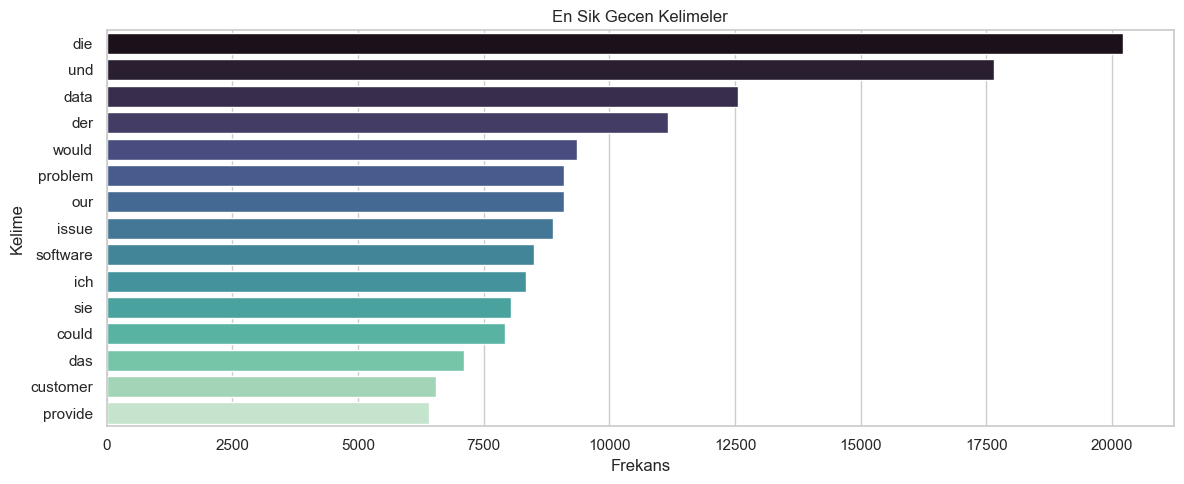

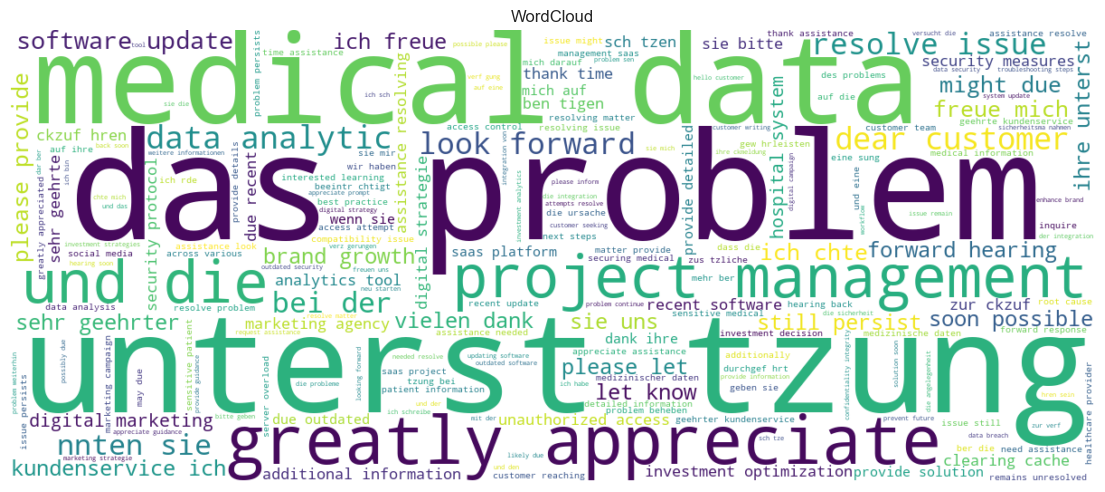

In [7]:
stopwords = {
    "the", "and", "for", "with", "that", "this", "from", "have", "been", "your", "you", "are",
    "bir", "ve", "ile", "icin", "cok", "ama", "gibi", "daha", "kadar", "ticket", "support"
}

def tokenize_text(series: pd.Series) -> list[str]:
    text = " ".join(series.fillna("").astype(str).tolist()).lower()
    tokens = re.findall(r"[a-zA-Z]{3,}", text)
    return [token for token in tokens if token not in stopwords]

if description_col in df.columns and df[description_col].fillna("").astype(str).str.len().sum() > 0:
    tokens = tokenize_text(df[description_col])
    top_words = pd.DataFrame(Counter(tokens).most_common(15), columns=["word", "frequency"])
    display(top_words)

    if not top_words.empty:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=top_words, x="frequency", y="word", palette="mako")
        plt.title("En Sik Gecen Kelimeler")
        plt.xlabel("Frekans")
        plt.ylabel("Kelime")
        plt.tight_layout()
        plt.show()

    if tokens:
        wordcloud = WordCloud(width=1200, height=500, background_color="white", colormap="viridis").generate(" ".join(tokens))
        plt.figure(figsize=(14, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title("WordCloud")
        plt.show()
    else:
        print("Description metninden anlamli token uretilemedi.")
else:
    print("Description benzeri kolon bulunamadigi icin NLP analizi guvenli bicimde atlandi.")


## 10. EDA

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
subject,24749,24749,Wesentlicher Sicherheitsvorfall,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,28587,28585,Assistance needed,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,28580,28580,Vielen Dank für die Meldung des kritischen Sic...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,28587,4,Incident,11466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,28587,10,Technical Support,8362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,28587,3,medium,11515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,28587,2,en,16338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,28587.0,NaN,NaN,NaN,278.382027,51.0,52.0,400.0,400.0,400.0,165.962935
tag_1,28587,116,Security,5880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tag_2,28574,256,Performance,5903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


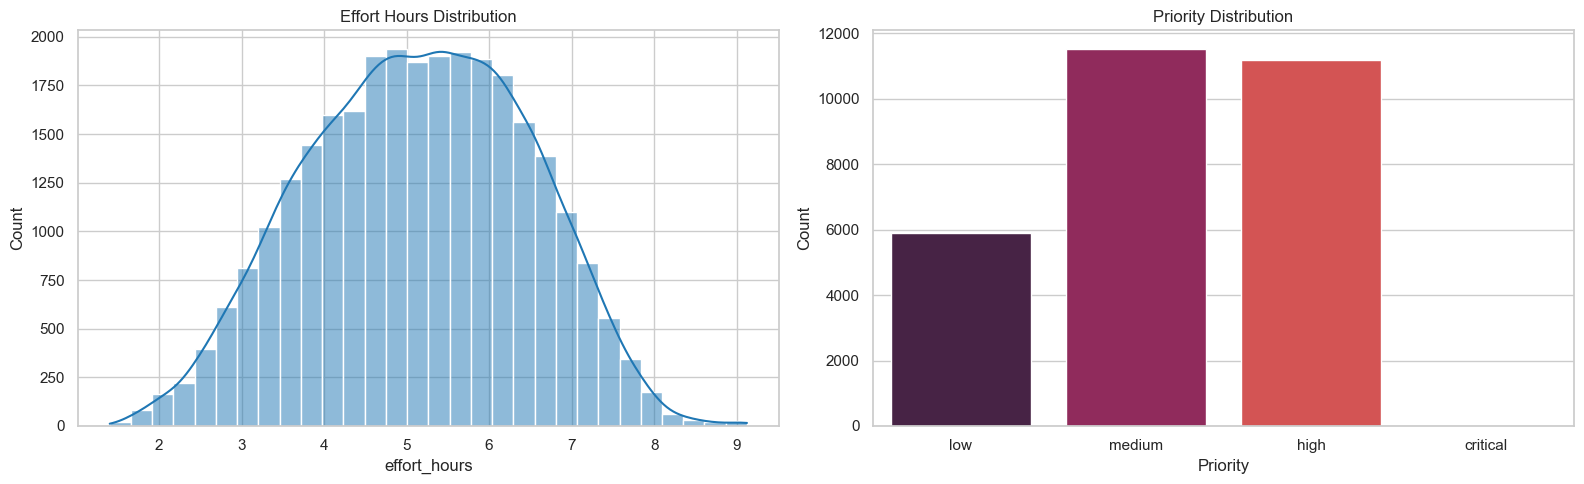

In [8]:
display(df.describe(include="all").transpose().head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["effort_hours"], bins=30, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Effort Hours Distribution")

priority_order = ["low", "medium", "high", "critical"]
priority_counts = df[priority_col].value_counts().reindex(priority_order).fillna(0)
sns.barplot(x=priority_counts.index, y=priority_counts.values, ax=axes[1], palette="rocket")
axes[1].set_title("Priority Distribution")
axes[1].set_xlabel("Priority")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 11. Pareto Analysis

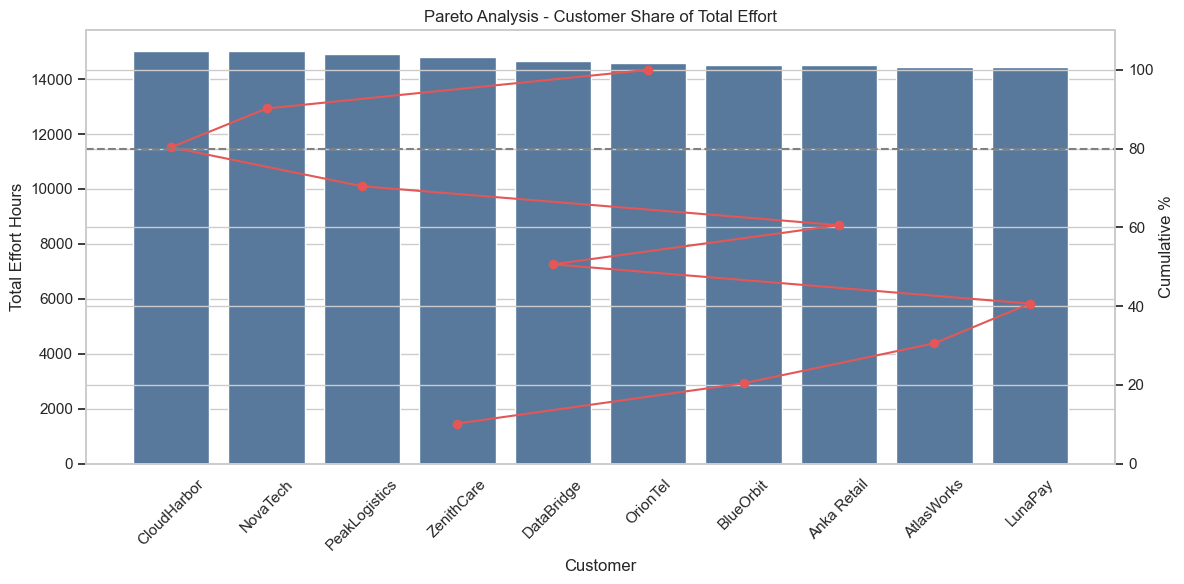

,customer_name,total_effort_hours,ticket_count,cum_pct
3,CloudHarbor,15018.840,2915,10.225959
6,NovaTech,15002.500,2901,20.440793
8,PeakLogistics,14905.060,2915,30.589282
9,ZenithCare,14789.125,2891,40.658833
4,DataBridge,14642.930,2846,50.628845
7,OrionTel,14601.690,2823,60.570777
2,BlueOrbit,14519.765,2833,70.456928
0,Anka Retail,14512.510,2829,80.338139
1,AtlasWorks,14454.475,2823,90.179836
5,LunaPay,14422.850,2811,100.000000


In [9]:
pareto_df = (
    df.groupby("customer_name", as_index=False)
    .agg(total_effort_hours=("effort_hours", "sum"), ticket_count=("customer_name", "size"))
    .sort_values("total_effort_hours", ascending=False)
)
pareto_df["cum_pct"] = pareto_df["total_effort_hours"].cumsum() / pareto_df["total_effort_hours"].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=pareto_df, x="customer_name", y="total_effort_hours", ax=ax1, color="#4c78a8")
ax1.set_title("Pareto Analysis - Customer Share of Total Effort")
ax1.set_xlabel("Customer")
ax1.set_ylabel("Total Effort Hours")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df["cum_pct"], color="#e45756", marker="o")
ax2.axhline(80, color="gray", linestyle="--")
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 110)
plt.tight_layout()
plt.show()

display(pareto_df.head(10))


## 12. Workload Heatmap and Seasonality

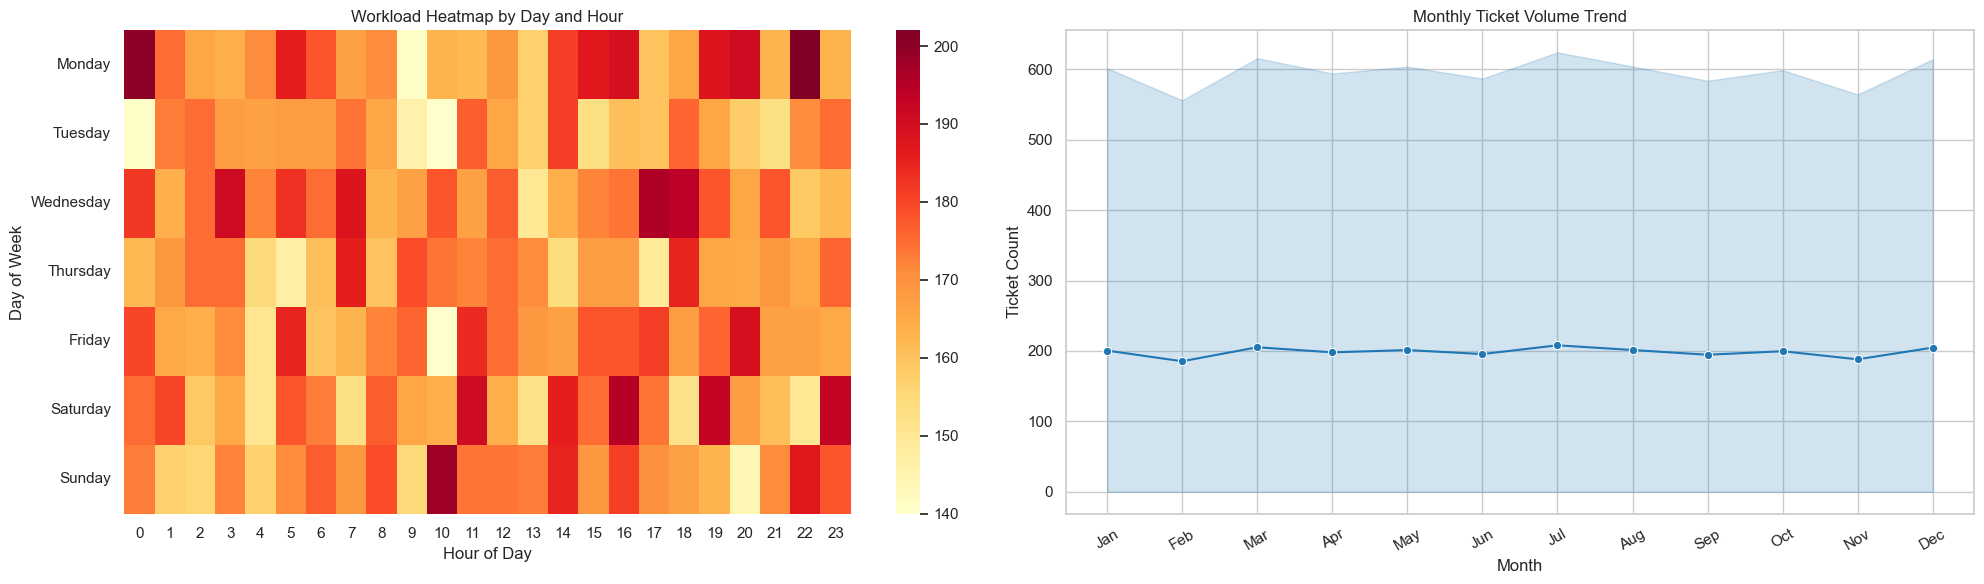

,created_month,created_month_name,ticket_count,avg_effort_hours
0,1,Jan,2406,5.101754
1,1,Feb,0,NaN
2,1,Mar,0,NaN
3,1,Apr,0,NaN
4,1,May,0,NaN
...,...,...,...,...
139,12,Aug,0,NaN
140,12,Sep,0,NaN
141,12,Oct,0,NaN
142,12,Nov,0,NaN


In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_df = (
    df.groupby(["created_day_of_week", "created_hour"])
    .size()
    .reset_index(name="ticket_count")
)
heatmap_pivot = (
    heatmap_df.pivot(index="created_day_of_week", columns="created_hour", values="ticket_count")
    .reindex(weekday_order)
    .fillna(0)
)

monthly_counts = (
    df.groupby(["created_month", "created_month_name"], observed=False)
    .size()
    .reset_index(name="ticket_count")
    .sort_values("created_month")
)
monthly_effort = (
    df.groupby(["created_month", "created_month_name"], observed=False)["effort_hours"]
    .mean()
    .reset_index(name="avg_effort_hours")
    .sort_values("created_month")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.heatmap(heatmap_pivot, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Workload Heatmap by Day and Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

sns.lineplot(data=monthly_counts, x="created_month_name", y="ticket_count", marker="o", sort=False, ax=axes[1], color="#1f77b4")
axes[1].set_title("Monthly Ticket Volume Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Ticket Count")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

display(monthly_counts.merge(monthly_effort, on=["created_month", "created_month_name"], how="left"))


## 13. Boxplot by Work Type

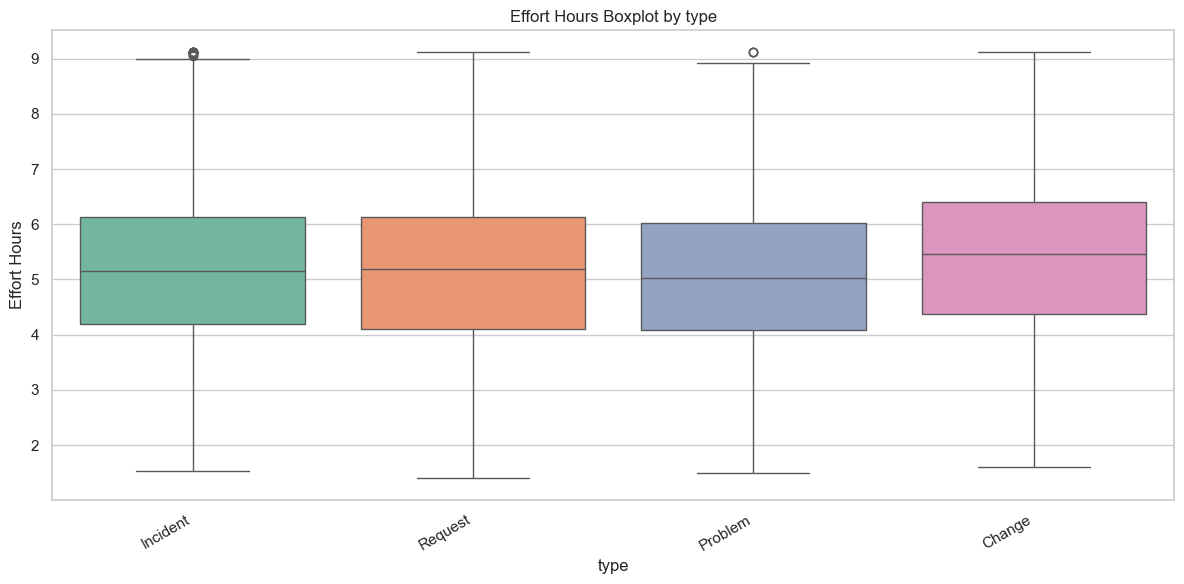

In [11]:
candidate_work_type_cols = [product_col, "type", "queue", priority_col]
work_type_col = next((col for col in candidate_work_type_cols if col is not None and col in df.columns), priority_col)
boxplot_df = df.copy()
top_work_types = boxplot_df[work_type_col].fillna("unknown").astype(str).value_counts().head(8).index.tolist()
boxplot_df[work_type_col] = boxplot_df[work_type_col].fillna("unknown").astype(str)
boxplot_df = boxplot_df[boxplot_df[work_type_col].isin(top_work_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=boxplot_df, x=work_type_col, y="effort_hours", order=top_work_types, palette="Set2")
plt.title(f"Effort Hours Boxplot by {work_type_col}")
plt.xlabel(work_type_col)
plt.ylabel("Effort Hours")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 14. Clustering

Bu bolumde musteri bazli segmentasyon icin `KMeans` kullanilmistir. Kumeleme sayisi sabit olarak `4` secilmistir.


,customer_name,avg_effort_hours,avg_resolution_time,avg_complexity_score,ticket_count,weekend_ratio,cluster
8,PeakLogistics,5.113228,9.002456,0.876160,2915,0.293654,0
3,CloudHarbor,5.152261,9.013499,0.887272,2915,0.295369,0
1,AtlasWorks,5.120253,8.912166,0.881108,2823,0.291888,1
5,LunaPay,5.130861,8.981939,0.887740,2811,0.285308,1
7,OrionTel,5.172402,9.022063,0.892155,2823,0.276656,1
9,ZenithCare,5.115574,8.976162,0.878559,2891,0.285022,2
6,NovaTech,5.171493,9.095533,0.890673,2901,0.294726,2
2,BlueOrbit,5.125226,8.995944,0.885976,2833,0.285210,3
0,Anka Retail,5.129908,8.922101,0.884486,2829,0.282785,3
4,DataBridge,5.145091,8.977505,0.885123,2846,0.275474,3


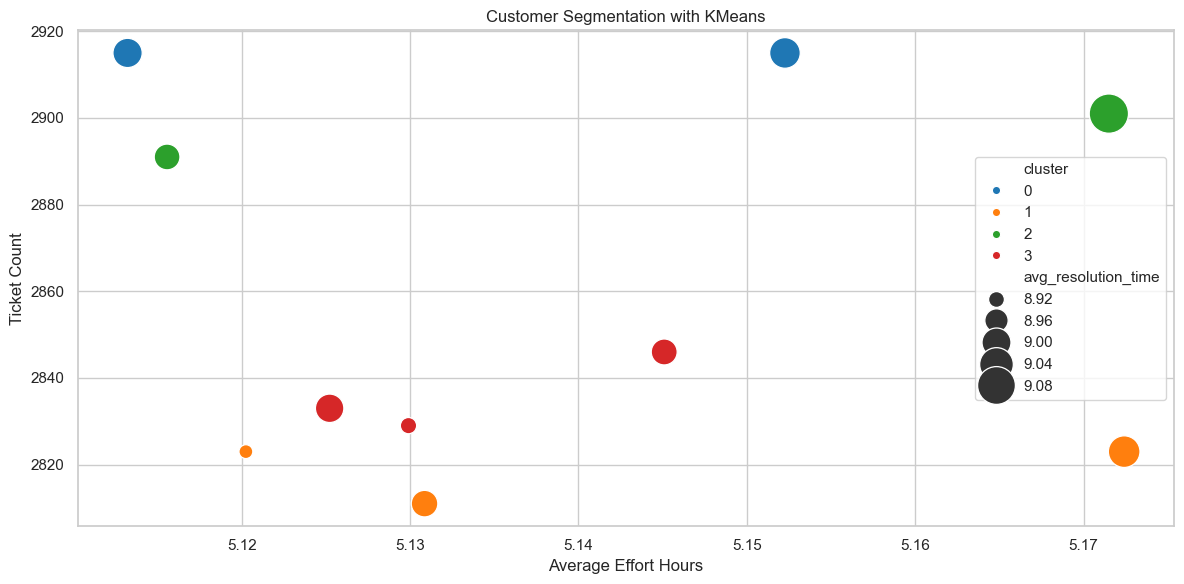

In [12]:
customer_agg = (
    df.groupby("customer_name")
    .agg(
        avg_effort_hours=("effort_hours", "mean"),
        avg_resolution_time=("resolution_time", "mean"),
        avg_complexity_score=("complexity_score", "mean"),
        ticket_count=("customer_name", "size"),
        weekend_ratio=("is_weekend", "mean")
    )
    .reset_index()
)

cluster_features = ["avg_effort_hours", "avg_resolution_time", "avg_complexity_score", "ticket_count", "weekend_ratio"]
kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=20)
customer_agg["cluster"] = kmeans.fit_predict(customer_agg[cluster_features])

display(customer_agg.sort_values(["cluster", "avg_effort_hours"]))

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=customer_agg,
    x="avg_effort_hours",
    y="ticket_count",
    hue="cluster",
    size="avg_resolution_time",
    sizes=(100, 800),
    palette="tab10"
)
plt.title("Customer Segmentation with KMeans")
plt.xlabel("Average Effort Hours")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()


## 15. Regression Modeling

Tahminleme hedefi olarak `effort_hours` kullanilmistir. Veri `%80 / %20` oraninda egitim ve test olarak ayrilmistir. Kategorik alanlarda One-Hot Encoding uygulanmistir.


In [13]:
def compute_rmse(y_true, y_pred):
    import numpy as np
    try:
        from sklearn.metrics import root_mean_squared_error
        return float(root_mean_squared_error(y_true, y_pred))
    except Exception:
        from sklearn.metrics import mean_squared_error
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))
feature_candidates = [
    "description_length", "word_count", "complexity_score", "is_weekend", "resolution_time",
    priority_col, "created_day_of_week", "customer_name"
]

if language_col is not None:
    feature_candidates.append(language_col)
if product_col is not None:
    feature_candidates.append(product_col)

feature_cols = [col for col in feature_candidates if col in df.columns]
model_df = df[feature_cols + ["effort_hours"]].copy()

X = model_df.drop(columns=["effort_hours"])
y = model_df["effort_hours"]

categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = [col for col in X.columns if col not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

numeric_preprocess_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocess_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_preprocess_scaled, numeric_features),
    ("cat", categorical_preprocess, categorical_features)
])

preprocessor_plain = ColumnTransformer([
    ("num", numeric_preprocess_plain, numeric_features),
    ("cat", categorical_preprocess, categorical_features)
])

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_plain),
        ("model", RandomForestRegressor(n_estimators=250, random_state=RANDOM_SEED))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor_plain),
        ("model", GradientBoostingRegressor(random_state=RANDOM_SEED))
    ])
}

results = []
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": compute_rmse(y_test, preds),
        "R2": r2_score(y_test, preds)
    })
    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)


,model,MAE,RMSE,R2
2,Gradient Boosting,0.334080,0.397627,0.911430
0,Linear Regression,0.339920,0.401059,0.909895
1,Random Forest,0.337332,0.407203,0.907113


## 16. Model Comparison

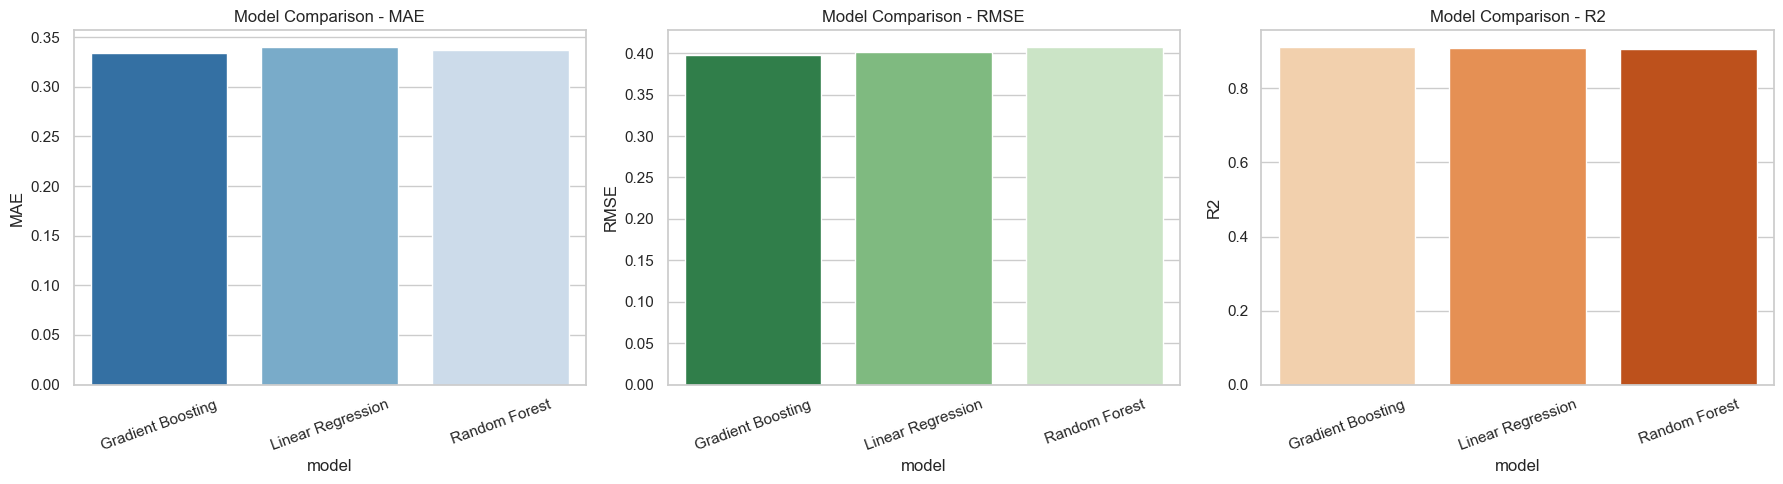

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_list = ["MAE", "RMSE", "R2"]
palettes = ["Blues_r", "Greens_r", "Oranges"]

for ax, metric, palette in zip(axes, metric_list, palettes):
    sns.barplot(data=results_df, x="model", y=metric, palette=palette, ax=ax)
    ax.set_title(f"Model Comparison - {metric}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 17. Feature Importance

,feature,importance
2,num__complexity_score,0.705106
4,num__resolution_time,0.103496
5,cat__priority_high,0.093434
6,cat__priority_low,0.054658
1,num__word_count,0.038958
7,cat__priority_medium,0.002276
0,num__description_length,0.001080
25,cat__language_de,0.000608
26,cat__language_en,0.000276
17,cat__customer_name_BlueOrbit,0.000033


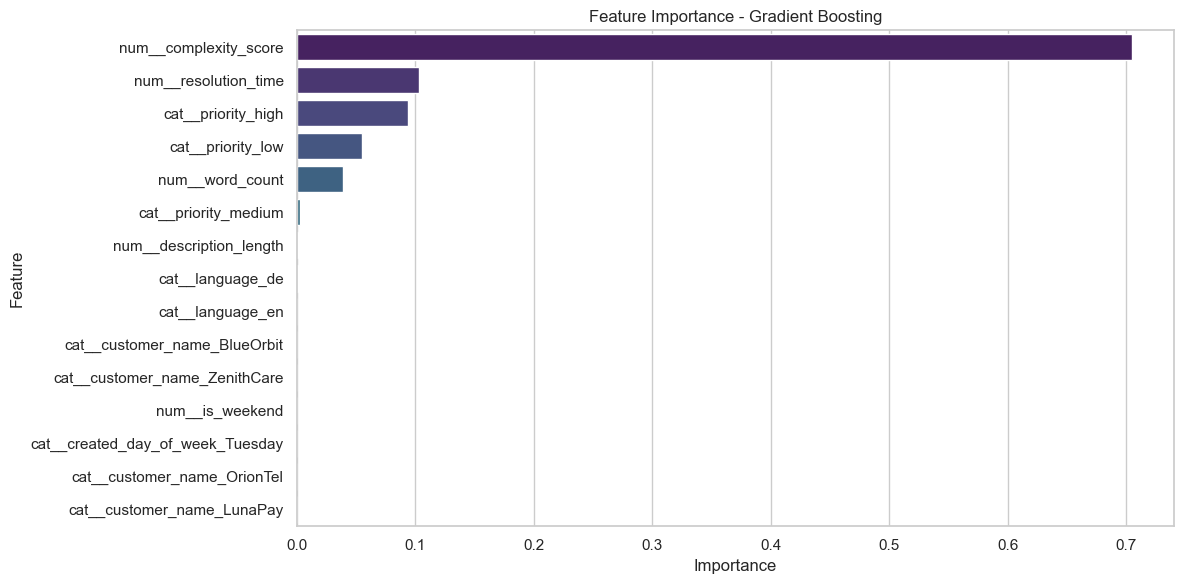

In [15]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_name]

if best_model_name in {"Random Forest", "Gradient Boosting"}:
    preprocessor = best_pipeline.named_steps["preprocessor"]
    model = best_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    importances = model.feature_importances_
    feature_importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    display(feature_importance_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("En iyi model Linear Regression oldugu icin standart feature importance grafigi yerine katsayi bazli yorum tercih edilmelidir.")


## 18. Insights

Bu bolumde analiz ciktlari is ve operasyon perspektifinden yorumlanir. `effort_hours` sentetik olarak uretildigi icin burada paylasilan bulgular gercek operasyonun birebir performans vaadi olarak degil, analitik simulasyon ve karar destek bakisiyla okunmalidir.


In [16]:
best_model_row = results_df.sort_values("RMSE").iloc[0]
best_model_name = best_model_row["model"]
complexity_effort_corr = df[["complexity_score", "effort_hours"]].corr().iloc[0, 1]
priority_effort = df.groupby(priority_col)["effort_hours"].mean().sort_values(ascending=False)
busiest_day = df["created_day_of_week"].value_counts().idxmax()
busiest_day_count = int(df["created_day_of_week"].value_counts().max())
busiest_hour = int(df["created_hour"].value_counts().idxmax())
busiest_hour_count = int(df["created_hour"].value_counts().max())
busiest_month_row = monthly_counts.sort_values("ticket_count", ascending=False).iloc[0]
weekend_effort = df.groupby("is_weekend")["effort_hours"].mean().to_dict()
weekend_label = "hafta sonu" if weekend_effort.get(1, 0) > weekend_effort.get(0, 0) else "hafta ici"
cluster_effort = customer_agg.groupby("cluster")["avg_effort_hours"].mean().sort_values(ascending=False)
most_expensive_cluster = int(cluster_effort.index[0])
most_expensive_cluster_effort = float(cluster_effort.iloc[0])
work_type_effort = boxplot_df.groupby(work_type_col)["effort_hours"].mean().sort_values(ascending=False)
top_customer_row = pareto_df.iloc[0]

insight_md = f"""
## Veri Tabanli Bulgular

- **En iyi model:** {best_model_name}. Test setinde MAE={best_model_row['MAE']:.3f}, RMSE={best_model_row['RMSE']:.3f}, R2={best_model_row['R2']:.3f} degerleri elde edilmistir.
- **MAE / RMSE / R2 yorumu:** MAE ortalama mutlak sapmayi, RMSE buyuk hatalara daha duyarli genel hata seviyesini, R2 ise modelin sentetik hedef varyansini ne kadar acikladigini gosterir.
- **Model guvenilirligi:** Model teknik olarak guclu gorunmektedir; ancak hedef degisken sentetik oldugu icin bu performans gercek operasyonel SLA basarisi degil, analitik mantigin ne kadar iyi ogrenildigini ifade eder.
- **Complexity ve effort iliskisi:** `complexity_score` ile `effort_hours` arasindaki korelasyon **{complexity_effort_corr:.2f}** seviyesindedir. Bu da daha karmasik ticket'larin daha yuksek efor tukettigini destekler.
- **Musteri segmentleri:** Ortalama eforu en yuksek segment **Cluster {most_expensive_cluster}** olup ortalama **{most_expensive_cluster_effort:.2f} saat** seviyesindedir.
- **Pareto bulgusu:** Toplam eforu en fazla tuketen musteri **{top_customer_row['customer_name']}** olup tek basina **{top_customer_row['total_effort_hours']:.1f} saat** efor olusturmaktadir.
- **Yogunluk deseni:** En yuksek ticket hacmi **{busiest_day}** gununde gorulmektedir ({busiest_day_count:,} ticket). Saat bazinda en yogun aralik **{busiest_hour}:00** olup **{busiest_hour_count:,}** ticket ile one cikmaktadir.
- **Aylik mevsimsellik:** En yuksek aylik talep **{busiest_month_row['created_month_name']}** doneminde gorulmustur ({int(busiest_month_row['ticket_count']):,} ticket).
- **Maliyetli is turu:** Ortalama efor bazinda en maliyetli kategori **{work_type_effort.index[0]}** olup ortalama **{work_type_effort.iloc[0]:.2f} saat** efor gerektirmektedir.
- **Hafta ici / hafta sonu etkisi:** Ortalama efor tarafinda **{weekend_label}** yukunun cok az farkla daha baskin oldugu izlenmektedir.

**Teknik not:** RMSE compatibility helper was used to support different scikit-learn versions.
"""
display(Markdown(insight_md))



## Veri Tabanli Bulgular

- **En iyi model:** Gradient Boosting. Test setinde MAE=0.334, RMSE=0.398, R2=0.911 degerleri elde edilmistir.
- **MAE / RMSE / R2 yorumu:** MAE ortalama mutlak sapmayi, RMSE buyuk hatalara daha duyarli genel hata seviyesini, R2 ise modelin sentetik hedef varyansini ne kadar acikladigini gosterir.
- **Model guvenilirligi:** Model teknik olarak guclu gorunmektedir; ancak hedef degisken sentetik oldugu icin bu performans gercek operasyonel SLA basarisi degil, analitik mantigin ne kadar iyi ogrenildigini ifade eder.
- **Complexity ve effort iliskisi:** `complexity_score` ile `effort_hours` arasindaki korelasyon **0.86** seviyesindedir. Bu da daha karmasik ticket'larin daha yuksek efor tukettigini destekler.
- **Musteri segmentleri:** Ortalama eforu en yuksek segment **Cluster 2** olup ortalama **5.14 saat** seviyesindedir.
- **Pareto bulgusu:** Toplam eforu en fazla tuketen musteri **CloudHarbor** olup tek basina **15018.8 saat** efor olusturmaktadir.
- **Yogunluk deseni:** En yuksek ticket hacmi **Wednesday** gununde gorulmektedir (4,175 ticket). Saat bazinda en yogun aralik **16:00** olup **1,246** ticket ile one cikmaktadir.
- **Aylik mevsimsellik:** En yuksek aylik talep **Jul** doneminde gorulmustur (2,496 ticket).
- **Maliyetli is turu:** Ortalama efor bazinda en maliyetli kategori **Change** olup ortalama **5.35 saat** efor gerektirmektedir.
- **Hafta ici / hafta sonu etkisi:** Ortalama efor tarafinda **hafta sonu** yukunun cok az farkla daha baskin oldugu izlenmektedir.

**Teknik not:** RMSE compatibility helper was used to support different scikit-learn versions.


## 19. Recommendations

1. **Complexity bazli uzman yonlendirme**
- Sorun: Yuksek complexity ticket'lar standart akista daha fazla zaman ve tekrar isleme neden olabilir.
- Veriyle gozlem: `complexity_score` ile `effort_hours` arasinda guclu pozitif iliski vardir.
- Onerilen aksiyon: Complexity esigi uzerindeki ticket'lar ilk asamada uzman ekip veya ikinci seviye destek kuyruguna aktarilmalidir.
- Beklenen operasyonel etki: Daha hizli cozum, daha az tekrar islem ve daha dengeli ekip kullanimi.

2. **Gun bazli kapasite planlama**
- Sorun: Ticket hacmi haftaya esit dagilmiyor.
- Veriyle gozlem: En yuksek hacim `Wednesday` gununde goruluyor; gun-saat heatmap'i belirli saat bloklarinda yukun toplandigini gosteriyor.
- Onerilen aksiyon: Vardiya ve back-up kapasite planlari gun ve saat bazli talep desenine gore optimize edilmelidir.
- Beklenen operasyonel etki: Backlog birikimi ve SLA sapmasi riski azalir.

3. **Yuksek efor tuketen segmentler icin SLA ve otomasyon tasarimi**
- Sorun: Bazi musteri segmentleri sistematik olarak daha yuksek efor tuketiyor.
- Veriyle gozlem: KMeans segmentasyonunda belirli cluster'lar daha yuksek ortalama efor uretiyor.
- Onerilen aksiyon: Bu segmentler icin ozel SLA, self-service icerikleri ve tekrar eden konu bazli otomasyon senaryolari tasarlanmalidir.
- Beklenen operasyonel etki: Kaynak tuketimi daha ongorulebilir hale gelir ve destek maliyeti kontrol altina alinabilir.


## 20. Executive Summary

- Proje, customer support ticket verilerinden efor ve kaynak kullanimini anlamak icin gelistirildi.
- Veri kaynagi olarak `tobiasbueck/multilingual-customer-support-tickets` dataseti kullanildi ve yerel proje klasorune kaydedildi.
- Gercek efor alani olmadigi icin `effort_hours` ve `resolution_time` analitik gosterim amaciyla sentetik olarak uretildi.
- Complexity, priority ve metin yogunlugu arttikca sentetik eforun da anlamli bicimde arttigi goruldu.
- Musteri Pareto analizi, toplam eforun belirli musteri gruplarinda toplandigini gosterdi.
- Gun-saat heatmap'i ve aylik trend grafikleri, is yukunun hem saat hem ay bazinda degistigini gorunur hale getirdi.
- Is turu bazli boxplot, bazi kategorilerde dagilimin ve aykiri degerlerin daha belirgin oldugunu gosterdi.
- Regresyon modellemede en iyi sonuc **Gradient Boosting** ile elde edildi.
- Bu performans gercek operasyonel tahmin basarisi olarak degil, sentetik efor mantiginin basarili sekilde ogrenilmesi olarak yorumlanmalidir.
- Onerilen aksiyon alanlari: uzman yonlendirme, gun ve saat bazli kapasite planlama ve segment bazli SLA / otomasyon tasarimi.
